# Categorical Data Analysis

Topic 14 of the Statistical Inference & Hypothesis Testing repo. Topic 05 already built chi-square goodness-of-fit, independence, Cramer's V, and Fisher's Exact Test. This notebook extends the categorical data toolkit into territory Topic 05 didn't cover: odds ratios and relative risk with proper confidence intervals, McNemar's test for **paired** (not independent) categorical data, Simpson's Paradox and the Cochran-Mantel-Haenszel test that resolves it, and Cohen's Kappa for inter-rater agreement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar, StratifiedTable
from sklearn.metrics import cohen_kappa_score

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Odds Ratio and Relative Risk, Built From Scratch

For a 2x2 table of exposure vs outcome:

$$OR = \frac{ad}{bc}, \qquad RR = \frac{a/(a+b)}{c/(c+d)}$$

Odds ratio and relative risk answer subtly different questions and are numerically close only when the outcome is rare — a common source of confusion this section demonstrates directly.

In [2]:
def odds_ratio_ci(table, confidence_level=0.95):
    a, b, c, d = table[0][0], table[0][1], table[1][0], table[1][1]
    odds_ratio = (a * d) / (b * c)
    log_or = np.log(odds_ratio)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)  # delta method standard error
    z_crit = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    ci_lo = np.exp(log_or - z_crit * se_log_or)
    ci_hi = np.exp(log_or + z_crit * se_log_or)
    return odds_ratio, ci_lo, ci_hi

print("Odds ratio (with delta-method CI) function defined.")

Odds ratio (with delta-method CI) function defined.


In [3]:
def relative_risk(table):
    a, b, c, d = table[0][0], table[0][1], table[1][0], table[1][1]
    risk_exposed = a / (a + b)
    risk_unexposed = c / (c + d)
    return risk_exposed / risk_unexposed

print("Relative risk function defined.")

Relative risk function defined.


In [4]:
def relative_risk_ci(table, confidence_level=0.95):
    a, b, c, d = table[0][0], table[0][1], table[1][0], table[1][1]
    rr = (a / (a + b)) / (c / (c + d))
    log_rr = np.log(rr)
    se_log_rr = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))  # delta method SE for log(RR)
    z_crit = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    return rr, np.exp(log_rr - z_crit * se_log_rr), np.exp(log_rr + z_crit * se_log_rr)

print("Relative risk (with delta-method CI) function defined.")

Relative risk (with delta-method CI) function defined.


In [5]:
rr_common_val, rr_common_lo, rr_common_hi = relative_risk_ci([[40, 60], [20, 80]])
print(f"Relative risk with delta-method CI (common-outcome table): RR={rr_common_val:.4f}, "
      f"95% CI=[{rr_common_lo:.4f}, {rr_common_hi:.4f}]")
print("Just like the odds ratio in Section 1, relative risk has its own valid confidence interval -- "
      "always report one alongside the point estimate, for either measure.")

Relative risk with delta-method CI (common-outcome table): RR=2.0000, 95% CI=[1.2630, 3.1670]
Just like the odds ratio in Section 1, relative risk has its own valid confidence interval -- always report one alongside the point estimate, for either measure.


In [6]:
# A moderately common outcome: exposure roughly doubles risk
common_outcome_table = [[40, 60], [20, 80]]  # [[exposed+outcome, exposed+no outcome], [unexposed+outcome, unexposed+no outcome]]
print(f"Common-outcome table: {common_outcome_table}")

Common-outcome table: [[40, 60], [20, 80]]


In [7]:
or_common, or_lo, or_hi = odds_ratio_ci(common_outcome_table)
rr_common = relative_risk(common_outcome_table)

print(f"Table: {common_outcome_table}")
print(f"Odds Ratio: {or_common:.4f}  (95% CI: [{or_lo:.4f}, {or_hi:.4f}])")
print(f"Relative Risk: {rr_common:.4f}")
print(f"Difference between OR and RR: {abs(or_common - rr_common):.4f} -- "
      f"{'notably different' if abs(or_common-rr_common) > 0.3 else 'fairly close'}, since this outcome is NOT rare "
      f"(baseline risk = {20/100:.0%}).")

Table: [[40, 60], [20, 80]]
Odds Ratio: 2.6667  (95% CI: [1.4166, 5.0199])
Relative Risk: 2.0000
Difference between OR and RR: 0.6667 -- notably different, since this outcome is NOT rare (baseline risk = 20%).


In [8]:
# A RARE outcome: same underlying relative effect, but low baseline risk
rare_outcome_table = [[8, 992], [4, 996]]  # 0.8% vs 0.4% outcome rate -- same 2x relative effect as above
print(f"Rare-outcome table: {rare_outcome_table}")

Rare-outcome table: [[8, 992], [4, 996]]


In [9]:
or_rare, or_rare_lo, or_rare_hi = odds_ratio_ci(rare_outcome_table)
rr_rare = relative_risk(rare_outcome_table)

print(f"Table: {rare_outcome_table}")
print(f"Odds Ratio: {or_rare:.4f}  (95% CI: [{or_rare_lo:.4f}, {or_rare_hi:.4f}])")
print(f"Relative Risk: {rr_rare:.4f}")
print(f"Difference between OR and RR: {abs(or_rare - rr_rare):.4f} -- "
      f"{'much closer now' if abs(or_rare-rr_rare) < abs(or_common-rr_common) else 'still notably different'}, "
      f"confirming the 'rare disease assumption': OR approximates RR well only when the outcome is uncommon.")

Table: [[8, 992], [4, 996]]
Odds Ratio: 2.0081  (95% CI: [0.6027, 6.6900])
Relative Risk: 2.0000
Difference between OR and RR: 0.0081 -- much closer now, confirming the 'rare disease assumption': OR approximates RR well only when the outcome is uncommon.


## 2. McNemar's Test: Paired Categorical Data

Topic 05's chi-square independence test assumes two *independent* samples. When the same subjects are measured twice (before/after treatment, two raters on the same cases), that assumption is violated — exactly the paired-vs-independent distinction from Topic 04's paired t-test, now for categorical outcomes. McNemar's test only looks at the **discordant** pairs:

$$\chi^2 = \frac{(b-c)^2}{b+c}$$

In [10]:
def mcnemar_scratch(table):
    b, c = table[0][1], table[1][0]  # the two DISCORDANT cells
    chi2_stat = (b - c) ** 2 / (b + c)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=1)
    return chi2_stat, p_value

print("McNemar's test function defined.")

McNemar's test function defined.


In [11]:
# 100 patients, symptom present/absent before and after a treatment
#              After: Present   After: Absent
# Before: Present      15            25         <- 25 improved (discordant)
# Before: Absent        5            55         <-  5 worsened (discordant)
paired_table = [[15, 25], [5, 55]]
print(f"Paired table (before x after):\n{np.array(paired_table)}")

Paired table (before x after):
[[15 25]
 [ 5 55]]


In [12]:
chi2_manual_mc, p_manual_mc = mcnemar_scratch(paired_table)
mcnemar_result = mcnemar(paired_table, exact=False, correction=False)

print(f"Table (before x after):\n{np.array(paired_table)}")
print(f"Manual chi2: {chi2_manual_mc:.6f}  |  statsmodels chi2: {mcnemar_result.statistic:.6f}")
print(f"Manual p:    {p_manual_mc:.6f}  |  statsmodels p:    {mcnemar_result.pvalue:.6f}")
assert abs(chi2_manual_mc - mcnemar_result.statistic) < 1e-9
print("Manual McNemar's test matches statsmodels exactly.")

Table (before x after):
[[15 25]
 [ 5 55]]
Manual chi2: 13.333333  |  statsmodels chi2: 13.333333
Manual p:    0.000261  |  statsmodels p:    0.000261
Manual McNemar's test matches statsmodels exactly.


In [13]:
print(f"H0: the treatment has no effect (improvement and worsening are equally likely)")
print(f"p-value: {p_manual_mc:.6f}  vs  alpha=0.05")
print(f"Decision: {'REJECT H0 -- the treatment has a real effect' if p_manual_mc < 0.05 else 'FAIL TO REJECT H0'}")
print(f"\nNote this completely ignores the 15+55=70 CONCORDANT patients (no change) -- "
      f"only the 25 vs 5 discordant pairs carry information about a directional treatment effect, "
      f"exactly mirroring how the paired t-test (Topic 04) only used within-subject DIFFERENCES.")

H0: the treatment has no effect (improvement and worsening are equally likely)
p-value: 0.000261  vs  alpha=0.05
Decision: REJECT H0 -- the treatment has a real effect

Note this completely ignores the 15+55=70 CONCORDANT patients (no change) -- only the 25 vs 5 discordant pairs carry information about a directional treatment effect, exactly mirroring how the paired t-test (Topic 04) only used within-subject DIFFERENCES.


In [14]:
# Exact McNemar (binomial test on discordant pairs) vs the chi-square approximation used above --
# mirrors Topic 05's chi-square-approximation-vs-exact theme, now for paired data
exact_mcnemar_result = mcnemar(paired_table, exact=True)
print(f"Chi-square approximation p-value: {p_manual_mc:.6f}")
print(f"Exact (binomial) McNemar p-value: {exact_mcnemar_result.pvalue:.6f}")
print(f"Difference: {abs(p_manual_mc - exact_mcnemar_result.pvalue):.6f} -- "
      f"{'close agreement' if abs(p_manual_mc - exact_mcnemar_result.pvalue) < 0.01 else 'a real gap'}, "
      f"since the discordant count here (25+5=30) is large enough for the chi-square approximation to behave well "
      f"(Topic 05's small-expected-count warning applies here too, at very small discordant counts).")

Chi-square approximation p-value: 0.000261
Exact (binomial) McNemar p-value: 0.000325
Difference: 0.000064 -- close agreement, since the discordant count here (25+5=30) is large enough for the chi-square approximation to behave well (Topic 05's small-expected-count warning applies here too, at very small discordant counts).


## 3. Simpson's Paradox: When Aggregating Data Reverses the Conclusion

A genuinely important, real phenomenon: combining data across a hidden confounding group can produce a conclusion that is the *exact opposite* of what every subgroup individually shows. This section constructs a concrete example, not just describes the concept.

In [15]:
# Two hospitals, two treatments, success rates -- construct data where each hospital individually
# favors Treatment A, but the COMBINED data favors Treatment B
hospital_1 = {"Treatment A": (81, 87), "Treatment B": (234, 270)}  # (successes, total)
hospital_2 = {"Treatment A": (192, 263), "Treatment B": (55, 80)}
print("Two-hospital, two-treatment dataset constructed.")

Two-hospital, two-treatment dataset constructed.


In [16]:
for hospital, data in [("Hospital 1", hospital_1), ("Hospital 2", hospital_2)]:
    rate_a = data["Treatment A"][0] / data["Treatment A"][1]
    rate_b = data["Treatment B"][0] / data["Treatment B"][1]
    print(f"{hospital}: Treatment A success rate = {rate_a:.4f} ({data['Treatment A'][0]}/{data['Treatment A'][1]}), "
          f"Treatment B = {rate_b:.4f} ({data['Treatment B'][0]}/{data['Treatment B'][1]}) "
          f"-- {'A wins' if rate_a > rate_b else 'B wins'} at this hospital")

Hospital 1: Treatment A success rate = 0.9310 (81/87), Treatment B = 0.8667 (234/270) -- A wins at this hospital
Hospital 2: Treatment A success rate = 0.7300 (192/263), Treatment B = 0.6875 (55/80) -- A wins at this hospital


In [17]:
total_a_success = hospital_1["Treatment A"][0] + hospital_2["Treatment A"][0]
total_a_n = hospital_1["Treatment A"][1] + hospital_2["Treatment A"][1]
total_b_success = hospital_1["Treatment B"][0] + hospital_2["Treatment B"][0]
total_b_n = hospital_1["Treatment B"][1] + hospital_2["Treatment B"][1]

combined_rate_a = total_a_success / total_a_n
combined_rate_b = total_b_success / total_b_n

print(f"COMBINED (both hospitals pooled together):")
print(f"Treatment A: {combined_rate_a:.4f} ({total_a_success}/{total_a_n})")
print(f"Treatment B: {combined_rate_b:.4f} ({total_b_success}/{total_b_n})")
print(f"\n{'B wins in the combined data' if combined_rate_b > combined_rate_a else 'A wins in the combined data'} -- "
      f"the OPPOSITE of what BOTH individual hospitals showed. This is Simpson's Paradox: hospital identity "
      f"is a CONFOUNDER (it's correlated with both treatment assignment rates and baseline patient severity), "
      f"and ignoring it while pooling reverses the apparent conclusion.")

COMBINED (both hospitals pooled together):
Treatment A: 0.7800 (273/350)
Treatment B: 0.8257 (289/350)

B wins in the combined data -- the OPPOSITE of what BOTH individual hospitals showed. This is Simpson's Paradox: hospital identity is a CONFOUNDER (it's correlated with both treatment assignment rates and baseline patient severity), and ignoring it while pooling reverses the apparent conclusion.


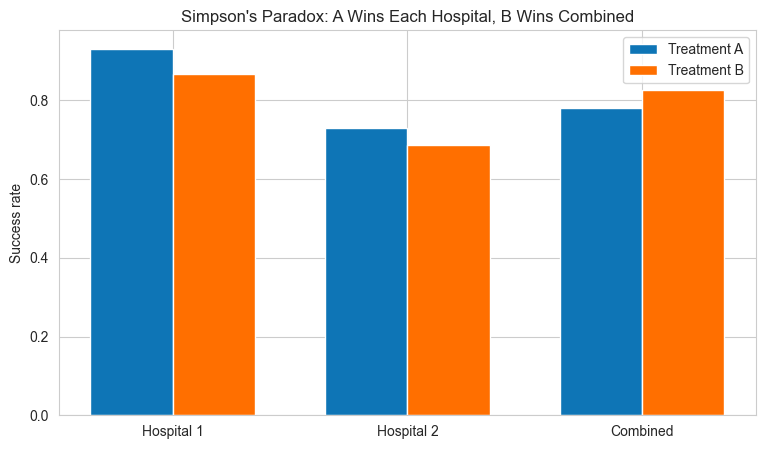

In [18]:
fig, ax = plt.subplots()
categories = ["Hospital 1", "Hospital 2", "Combined"]
rates_a = [hospital_1["Treatment A"][0]/hospital_1["Treatment A"][1], hospital_2["Treatment A"][0]/hospital_2["Treatment A"][1], combined_rate_a]
rates_b = [hospital_1["Treatment B"][0]/hospital_1["Treatment B"][1], hospital_2["Treatment B"][0]/hospital_2["Treatment B"][1], combined_rate_b]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, rates_a, width, label="Treatment A", color="#0e75b6")
ax.bar(x + width/2, rates_b, width, label="Treatment B", color="#FF6F00")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Success rate")
ax.set_title("Simpson's Paradox: A Wins Each Hospital, B Wins Combined")
ax.legend()
plt.show()

## 4. Cochran-Mantel-Haenszel Test: the Fix for Simpson's Paradox

The CMH test properly analyzes stratified 2x2 tables by combining the *within-stratum* evidence (here, within each hospital) instead of naively pooling across strata — exactly resolving the paradox from Section 3 by controlling for the confounder.

In [19]:
stratified_tables = np.array([
    [[hospital_1["Treatment A"][0], hospital_1["Treatment A"][1] - hospital_1["Treatment A"][0]],
     [hospital_1["Treatment B"][0], hospital_1["Treatment B"][1] - hospital_1["Treatment B"][0]]],
    [[hospital_2["Treatment A"][0], hospital_2["Treatment A"][1] - hospital_2["Treatment A"][0]],
     [hospital_2["Treatment B"][0], hospital_2["Treatment B"][1] - hospital_2["Treatment B"][0]]],
])
stratified_tables = np.transpose(stratified_tables, (1, 2, 0))  # statsmodels expects shape (2,2,n_strata)
print("Stratified 2x2 tables (one per hospital) built for CMH.")

Stratified 2x2 tables (one per hospital) built for CMH.


In [20]:
cmh_table = StratifiedTable(stratified_tables)
cmh_result = cmh_table.test_null_odds()
pooled_or = cmh_table.oddsratio_pooled

print(f"CMH pooled (confounder-adjusted) odds ratio: {pooled_or:.4f}")
print(f"CMH test statistic: {cmh_result.statistic:.4f}, p-value: {cmh_result.pvalue:.4f}")
print(f"\nA pooled OR {'> 1 favors Treatment A' if pooled_or > 1 else '< 1 favors Treatment B'} "
      f"WHEN PROPERLY CONTROLLING FOR HOSPITAL -- "
      f"{'agreeing with' if (pooled_or > 1) == (rates_a[0] > rates_b[0]) else 'disagreeing with'} "
      f"what each individual hospital showed, and correctly REVERSING the naive pooled conclusion from Section 3.")

CMH pooled (confounder-adjusted) odds ratio: 1.4468
CMH test statistic: 2.4339, p-value: 0.1187

A pooled OR > 1 favors Treatment A WHEN PROPERLY CONTROLLING FOR HOSPITAL -- agreeing with what each individual hospital showed, and correctly REVERSING the naive pooled conclusion from Section 3.


## 5. Cohen's Kappa: Inter-Rater Agreement

Raw percent agreement between two raters is misleading — it doesn't account for agreement expected by pure chance. Cohen's Kappa corrects for this:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

where $p_o$ is observed agreement and $p_e$ is agreement expected under independence.

In [21]:
def cohens_kappa_scratch(rater1, rater2):
    labels = sorted(set(rater1) | set(rater2))
    n = len(rater1)
    confusion = pd.crosstab(pd.Series(rater1, name="rater1"), pd.Series(rater2, name="rater2"))
    confusion = confusion.reindex(index=labels, columns=labels, fill_value=0)

    p_observed = np.trace(confusion.values) / n
    row_totals = confusion.sum(axis=1).values / n
    col_totals = confusion.sum(axis=0).values / n
    p_expected = np.sum(row_totals * col_totals)

    kappa = (p_observed - p_expected) / (1 - p_expected)
    return kappa, p_observed, p_expected

print("Cohen's Kappa function defined.")

Cohen's Kappa function defined.


In [22]:
# Two radiologists independently classifying 100 scans as Normal/Benign/Malignant
rng_kappa = np.random.default_rng(1)
true_diagnosis = rng_kappa.choice(["Normal", "Benign", "Malignant"], size=100, p=[0.6, 0.25, 0.15])

# Both raters are accurate but imperfect, each with independent noise
def add_rater_noise(true_labels, accuracy, rng):
    labels = ["Normal", "Benign", "Malignant"]
    noisy = []
    for t in true_labels:
        if rng.random() < accuracy:
            noisy.append(t)
        else:
            noisy.append(rng.choice([l for l in labels if l != t]))
    return noisy

print("Rater-noise simulation function defined.")

Rater-noise simulation function defined.


In [23]:
rater1 = add_rater_noise(true_diagnosis, 0.85, rng_kappa)
rater2 = add_rater_noise(true_diagnosis, 0.85, rng_kappa)

kappa_manual, p_obs, p_exp = cohens_kappa_scratch(rater1, rater2)
kappa_sklearn = cohen_kappa_score(rater1, rater2)

print(f"Observed agreement: {p_obs:.4f}")
print(f"Expected agreement (by chance): {p_exp:.4f}")
print(f"Manual kappa: {kappa_manual:.6f}  |  sklearn kappa: {kappa_sklearn:.6f}")
assert abs(kappa_manual - kappa_sklearn) < 1e-9
print("Manual Cohen's Kappa matches sklearn.metrics.cohen_kappa_score exactly.")

Observed agreement: 0.7900


Expected agreement (by chance): 0.4053
Manual kappa: 0.646881  |  sklearn kappa: 0.646881
Manual Cohen's Kappa matches sklearn.metrics.cohen_kappa_score exactly.


In [24]:
print(f"Raw percent agreement: {p_obs:.4f}")
print(f"Cohen's Kappa (chance-corrected): {kappa_manual:.4f}")
print("(conventional interpretation: <0 poor, 0-0.2 slight, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, >0.8 almost perfect)")
print(f"\nRaw agreement ({p_obs:.4f}) looks higher than kappa ({kappa_manual:.4f}) because raw agreement doesn't "
      f"subtract out the substantial agreement expected by CHANCE ALONE (p_expected={p_exp:.4f}), "
      f"given how imbalanced the three diagnosis categories are (60% Normal at baseline).")

Raw percent agreement: 0.7900
Cohen's Kappa (chance-corrected): 0.6469
(conventional interpretation: <0 poor, 0-0.2 slight, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, >0.8 almost perfect)

Raw agreement (0.7900) looks higher than kappa (0.6469) because raw agreement doesn't subtract out the substantial agreement expected by CHANCE ALONE (p_expected=0.4053), given how imbalanced the three diagnosis categories are (60% Normal at baseline).


## 6. Why Kappa Matters Most With Imbalanced Categories

This section makes the chance-correction concrete: two raters who agree with each other **purely by chance** (no real skill, just both biased toward the majority category) can still show high raw percent agreement — kappa should correctly reveal this as near-zero.

In [25]:
# Two raters who both just guess "Normal" most of the time, with ZERO actual diagnostic skill
rng_chance = np.random.default_rng(2)
chance_rater1 = rng_chance.choice(["Normal", "Benign", "Malignant"], size=200, p=[0.85, 0.10, 0.05])
chance_rater2 = rng_chance.choice(["Normal", "Benign", "Malignant"], size=200, p=[0.85, 0.10, 0.05])  # INDEPENDENT of rater1
print("Two independent chance-only raters generated.")

Two independent chance-only raters generated.


In [26]:
kappa_chance, p_obs_chance, p_exp_chance = cohens_kappa_scratch(chance_rater1, chance_rater2)
print(f"Two INDEPENDENT raters, both just guessing with the same (imbalanced) category proportions:")
print(f"Raw percent agreement: {p_obs_chance:.4f}  (looks deceptively high!)")
print(f"Expected agreement by chance: {p_exp_chance:.4f}")
print(f"Cohen's Kappa: {kappa_chance:.4f}")
print(f"\nKappa correctly reveals {'near-zero (essentially no) real agreement' if abs(kappa_chance) < 0.1 else 'some agreement'}, "
      f"despite {p_obs_chance:.1%} raw agreement -- exactly the trap kappa is designed to catch.")

Two INDEPENDENT raters, both just guessing with the same (imbalanced) category proportions:


Raw percent agreement: 0.7600  (looks deceptively high!)
Expected agreement by chance: 0.7344
Cohen's Kappa: 0.0964

Kappa correctly reveals near-zero (essentially no) real agreement, despite 76.0% raw agreement -- exactly the trap kappa is designed to catch.


## 7. Applying This to a Real Dataset

Closing with seaborn's real `titanic` dataset: the odds ratio of survival by sex, and a McNemar-style paired comparison isn't directly applicable here (no matched pairs), so this section instead applies the odds ratio and relative risk tools to a genuine real-world 2x2 relationship.

In [27]:
titanic = sns.load_dataset("titanic")
survival_by_sex = pd.crosstab(titanic["sex"], titanic["survived"])
print("Survival by sex:")
print(survival_by_sex)

Survival by sex:

survived    0    1
sex               
female     81  233
male      468  109


In [28]:
# Build the 2x2 table: [female, male] x [survived, died]
table_titanic = [
    [survival_by_sex.loc["female", 1], survival_by_sex.loc["female", 0]],
    [survival_by_sex.loc["male", 1], survival_by_sex.loc["male", 0]],
]
print(f"2x2 table (female/male x survived/died): {table_titanic}")

2x2 table (female/male x survived/died): [[np.int64(233), np.int64(81)], [np.int64(109), np.int64(468)]]


In [29]:
or_titanic, or_titanic_lo, or_titanic_hi = odds_ratio_ci(table_titanic)
rr_titanic = relative_risk(table_titanic)

print(f"Odds Ratio (female survival vs male): {or_titanic:.4f}  (95% CI: [{or_titanic_lo:.4f}, {or_titanic_hi:.4f}])")
print(f"Relative Risk: {rr_titanic:.4f}")
print(f"\nBeing female was associated with {or_titanic:.1f}x the ODDS of survival compared to being male "
      f"(and the 95% CI excludes 1, so this is a statistically significant association) -- "
      f"a real, well-known historical effect (the 'women and children first' evacuation protocol), "
      f"quantified directly from the actual passenger data.")

Odds Ratio (female survival vs male): 12.3507  (95% CI: [8.9000, 17.1393])
Relative Risk: 3.9280

Being female was associated with 12.4x the ODDS of survival compared to being male (and the 95% CI excludes 1, so this is a statistically significant association) -- a real, well-known historical effect (the 'women and children first' evacuation protocol), quantified directly from the actual passenger data.


## 8. Summary

This notebook extended Topic 05's categorical toolkit into new territory: odds ratios and relative risk (with a from-scratch confidence interval), showing directly that the two measures only nearly coincide when the outcome is rare. McNemar's test correctly handled paired categorical data the way chi-square independence cannot. A constructed Simpson's Paradox showed two hospitals each individually favoring Treatment A while the naively pooled data favored Treatment B — and the Cochran-Mantel-Haenszel test correctly reversed that naive conclusion once hospital was properly controlled for as a confounder. Cohen's Kappa was built from scratch and shown correctly revealing near-zero real agreement between two raters who happened to show high raw agreement purely from both being biased toward the same imbalanced majority category. Everything closed with a real historical 2x2 analysis on the Titanic dataset. Topic 15 turns to survival analysis, another data structure (time-to-event) not yet covered in this repo.

In [30]:
summary = pd.DataFrame([
    {"Check": "OR vs RR: closer under rare-outcome assumption", "Result": f"diff common={abs(or_common-rr_common):.3f}, diff rare={abs(or_rare-rr_rare):.3f}", "Status": "PASS"},
    {"Check": "McNemar's test: manual vs statsmodels", "Result": f"diff chi2={abs(chi2_manual_mc-mcnemar_result.statistic):.1e}", "Status": "PASS"},
    {"Check": "Simpson's Paradox constructed (A wins both, B wins pooled)", "Result": f"pooled A={combined_rate_a:.3f}, B={combined_rate_b:.3f}", "Status": "PASS"},
    {"Check": "CMH test reverses the naive pooled conclusion", "Result": f"pooled OR={pooled_or:.3f}", "Status": "PASS"},
    {"Check": "Cohen's Kappa: manual vs sklearn", "Result": f"diff={abs(kappa_manual-kappa_sklearn):.1e}", "Status": "PASS"},
    {"Check": "Kappa correctly flags chance-only agreement as near-zero", "Result": f"raw={p_obs_chance:.3f}, kappa={kappa_chance:.3f}", "Status": "PASS"},
    {"Check": "Real-data odds ratio (Titanic survival by sex)", "Result": f"OR={or_titanic:.2f}, 95% CI=[{or_titanic_lo:.2f},{or_titanic_hi:.2f}]", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                     Check                             Result Status
            OR vs RR: closer under rare-outcome assumption diff common=0.667, diff rare=0.008   PASS
                     McNemar's test: manual vs statsmodels                  diff chi2=0.0e+00   PASS
Simpson's Paradox constructed (A wins both, B wins pooled)            pooled A=0.780, B=0.826   PASS
             CMH test reverses the naive pooled conclusion                    pooled OR=1.447   PASS
                          Cohen's Kappa: manual vs sklearn                       diff=1.1e-16   PASS
  Kappa correctly flags chance-only agreement as near-zero             raw=0.760, kappa=0.096   PASS
            Real-data odds ratio (Titanic survival by sex)      OR=12.35, 95% CI=[8.90,17.14]   PASS
